# Optimizing Model Prediction

For this guided project, Instead of going with a single model, we'll start with a reference model and then iterate on it using various techniques to optimize it. Our reference model will be a standard linear regression model, and our machine learning task will be to predict the extent of fire damage to a forest.

Our data comes from the [Forest Fires](https://archive.ics.uci.edu/ml/datasets/Forest+Fires) dataset from the UCI Machine Learning Repository. This dataset contains information on fires, along with the resulting damage and associated meteorological data. We want to know how these characteristics might be useful in predicting future fire damage.

## Explore the dataset

In [1]:
# import necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
%matplotlib inline

In [2]:
# Read the dataset
fires = pd.read_csv('../../dataset/fires.csv', )
fires.head()

,Unnamed: 0,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,1,7,5,mar,fri,86.2,26.2,94.3,5.1,NaN,51.0,6.7,0.0,0.0
1,2,7,4,oct,tue,90.6,NaN,669.1,6.7,18.0,33.0,0.9,0.0,0.0
2,3,7,4,oct,sat,90.6,43.7,NaN,6.7,14.6,33.0,1.3,0.0,0.0
3,4,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97.0,4.0,0.2,0.0
4,5,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99.0,NaN,0.0,0.0


In [3]:
fires.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  517 non-null    int64  
 1   X           517 non-null    int64  
 2   Y           517 non-null    int64  
 3   month       517 non-null    object 
 4   day         517 non-null    object 
 5   FFMC        469 non-null    float64
 6   DMC         496 non-null    float64
 7   DC          474 non-null    float64
 8   ISI         515 non-null    float64
 9   temp        496 non-null    float64
 10  RH          487 non-null    float64
 11  wind        482 non-null    float64
 12  rain        485 non-null    float64
 13  area        517 non-null    float64
dtypes: float64(9), int64(3), object(2)
memory usage: 56.7+ KB


In [4]:
# check the missing value
fires.isna().sum()

Unnamed: 0     0
X              0
Y              0
month          0
day            0
FFMC          48
DMC           21
DC            43
ISI            2
temp          21
RH            30
wind          35
rain          32
area           0
dtype: int64

We will drop the missing value rows in wind and temp column as these are your selected feature for initial model.

In [5]:
# select the features
X = fires[['temp', 'wind']].dropna()
y = fires['area']

# Instantiate the model
model = LinearRegression()


## Data Processing

First, we'll convert the `month` column into a categorical feature. Instead of using the strings, we'll convert it into an indicator for the summer months in the northern hemisphere.

For the sake of completion, we'll impute all of the features so that we can have the biggest set to choose from for sequential feature selection. We'll go with K-nearest neighbors imputation since we expect area damage to be similar among similar fires. 

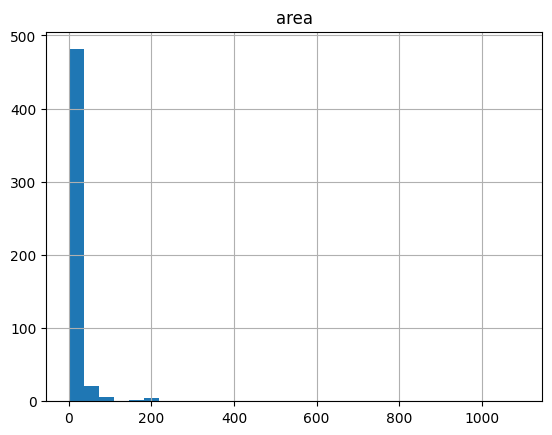

In [6]:
# Examine the distribution of area column
fires.hist('area', bins = 30)
plt.show()

The outcome is highly right-skewed with extremely damaging fires. Furthermore, many of the rows have outcome values that are zero or near-zero. It might be worth it to log-transform the data. Note though that some of the outcomes are actually 0, so we can add `1` to prevent any errors. Recall that $log(0)$ is undefined.

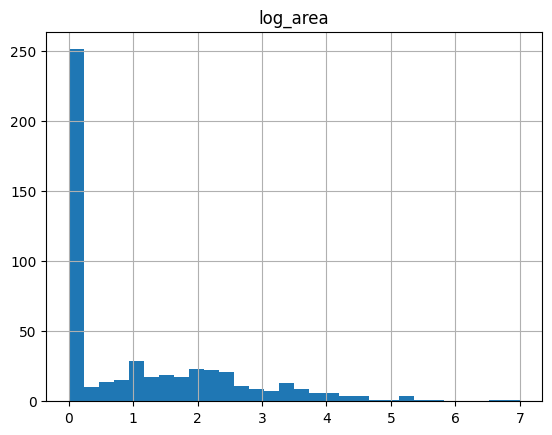

In [7]:
fires['log_area'] = np.log(fires['area'] + 1)
fires.hist('log_area', bins = 30)
plt.show()

We can see that performing a log-transformation doesn't produce a normal distribution, but it does spread out the data a bit more than without the transformation. It's probably the case that most fires do not appreciably damage the forest, so we would be mistaken in removing all of these rows. 

Instead of using `month` directly, we'll derive another feature called `summer` that takes a value of 1 when the fire occurred during the summer. The idea here is that summer months are typically hotter, so fires are more likely. 

In [8]:
def is_summer(x):
    if x in ['jun', 'jul', 'aug']:
        return 1
    else:
        return 0
fires['summer'] = fires['month'].apply(is_summer)
fires.sample(10)

,Unnamed: 0,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,log_area,summer
308,309,2,4,sep,sun,92.4,105.8,758.1,9.9,16.0,45.0,1.8,0.0,0.00,0.000000,0
266,267,6,5,aug,tue,94.3,131.7,607.1,22.7,19.4,55.0,NaN,0.0,0.17,0.157004,1
27,28,7,4,sep,mon,90.9,126.5,686.5,7.0,19.4,48.0,1.3,0.0,0.00,0.000000,0
390,391,7,4,feb,mon,84.7,9.5,58.3,4.1,7.5,71.0,6.3,0.0,9.96,2.394252,0
272,273,2,5,aug,tue,92.1,152.6,658.2,14.3,20.2,47.0,4.0,0.0,3.09,1.408545,1
91,92,8,6,mar,fri,91.7,35.8,80.8,7.8,17.4,24.0,5.4,0.0,0.00,0.000000,0
157,158,2,2,aug,wed,NaN,111.2,654.1,9.6,18.4,45.0,3.6,0.0,1.63,0.966984,1
235,236,8,6,aug,sun,91.4,142.4,NaN,10.6,19.6,41.0,5.8,0.0,196.48,5.285637,1
54,55,4,3,aug,thu,91.7,114.3,661.3,6.3,17.6,45.0,NaN,0.0,0.00,0.000000,1
81,82,1,2,aug,sun,90.2,99.6,631.2,6.3,17.9,44.0,2.2,0.0,0.00,0.000000,1


We will impute the missing value of other feature using knn imputer.

In [9]:
from sklearn.impute import KNNImputer

imp = KNNImputer(missing_values = np.nan, n_neighbors=3)

fires_missing = fires[fires.columns[5:13]] # FFMC to rain
imputed = pd.DataFrame(imp.fit_transform(fires_missing), 
                       columns = fires.columns[5:13])
imputed

,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,86.2,26.200000,94.300000,5.1,16.6,51.0,6.700000,0.0
1,90.6,56.433333,669.100000,6.7,18.0,33.0,0.900000,0.0
2,90.6,43.700000,470.833333,6.7,14.6,33.0,1.300000,0.0
3,91.7,33.300000,77.500000,9.0,8.3,97.0,4.000000,0.2
4,89.3,51.300000,102.200000,9.6,11.4,99.0,4.333333,0.0
...,...,...,...,...,...,...,...,...
512,81.6,56.700000,665.600000,1.9,27.8,32.0,2.700000,0.0
513,81.6,56.700000,665.600000,1.9,21.9,71.0,5.800000,0.0
514,81.6,56.700000,665.600000,1.9,21.2,70.0,6.700000,0.0
515,94.4,146.000000,614.700000,11.3,25.6,42.0,4.000000,0.0


Now, we will examine the outliers.

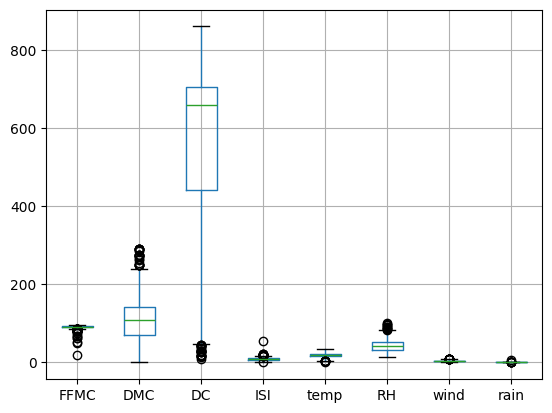

In [10]:
imputed.boxplot()
plt.show()

The dots indicate that there are some outliers in the data. Let's examine the number of outliers in each of the columns.

In [12]:
for col in imputed:
    quartiles = np.percentile(fires[col],[25, 50, 75])
    iqr = quartiles[2] - quartiles[0]
    lower_bound = quartiles[0] - (1.5* iqr)
    upper_bound = quartiles[2] + (1.5 * iqr)
    num_outliers =sum((imputed[col] < lower_bound) | (imputed[col] > upper_bound))

    print(f"The {col} column has {num_outliers} according to the boxplot method.")
    

The FFMC column has 0 according to the boxplot method.
The DMC column has 0 according to the boxplot method.
The DC column has 0 according to the boxplot method.
The ISI column has 0 according to the boxplot method.
The temp column has 0 according to the boxplot method.
The RH column has 0 according to the boxplot method.
The wind column has 0 according to the boxplot method.
The rain column has 0 according to the boxplot method.


Despite the visual cue in the boxplots, based on the actual calculations, there don't seem to be any outliers. In this case, we'll leave the dataset as-is. 

Now that the dataset has been inspected for missing values and outliers, we can proceed to standardize it. These standardized values will help for standardization. Afterwards, we'll append the `summmer` feature back into the dataset. 

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(imputed)
scaled = pd.DataFrame(scaled, columns = imputed.columns)

final = pd.concat([scaled, fires['summer']], axis = 1)

In [14]:
final.sample(10)

,FFMC,DMC,DC,ISI,temp,RH,wind,rain,summer
387,0.043916,-1.451100,-2.107838,-0.223183,-1.264954,0.229678,0.780071,-0.073268,0
108,0.335388,-0.361043,0.630513,-0.420874,0.243220,0.040629,-0.518700,-0.073268,0
132,-0.247556,-0.939988,-1.814327,0.128267,-1.438308,0.103646,0.497729,-0.073268,0
484,0.772595,0.306243,0.173438,1.116722,2.462143,-1.219694,-0.010485,-0.073268,1
190,0.098567,-0.987313,-1.832364,0.765271,-1.247619,-0.715565,-0.010485,-0.073268,0
245,0.207869,1.012966,0.491545,1.050825,1.370017,-0.400484,1.288285,-0.073268,1
396,-0.028952,-0.223800,0.843268,0.523649,0.260555,0.670791,0.497729,-0.073268,0
472,-0.447943,-0.231687,-1.294532,-0.948049,-0.796900,2.183179,-0.010485,-0.073268,1
470,0.268592,-1.518933,-2.029268,0.721340,-0.224834,-1.093662,1.005944,-0.073268,0
120,0.153218,0.544447,0.259933,0.369890,-1.490314,1.868099,-1.026915,-0.073268,1


## Subset Selection
There are quite a few features in the dataset, so let's use feature selection to determine which features might be useful for generating predictions. 

In [15]:
from sklearn.feature_selection import SequentialFeatureSelector

y = fires["log_area"]

sfs_model = LinearRegression()
sfs_model2 = LinearRegression()
sfs_model3 = LinearRegression()

forward2 = SequentialFeatureSelector(estimator=sfs_model,
                                     n_features_to_select=2, 
                                     direction="forward")

forward4 = SequentialFeatureSelector(estimator=sfs_model2,
                                     n_features_to_select=4, 
                                     direction="forward")

forward6 = SequentialFeatureSelector(estimator=sfs_model3,
                                       n_features_to_select=6, 
                                       direction="forward")

forward2.fit(final, y)
forward4.fit(final, y)
forward6.fit(final, y)

print("Features selected in 2 feature model:", forward2.get_feature_names_out())
print("Features selected in 4 feature model:", forward4.get_feature_names_out())
print("Features selected in 6 feature model:", forward6.get_feature_names_out())

Features selected in 2 feature model: ['FFMC' 'DC']
Features selected in 4 feature model: ['FFMC' 'DC' 'RH' 'wind']
Features selected in 6 feature model: ['FFMC' 'DC' 'ISI' 'RH' 'wind' 'summer']


In [16]:
backward2 = SequentialFeatureSelector(estimator=sfs_model,
                                     n_features_to_select=2, 
                                     direction="backward")

backward4 = SequentialFeatureSelector(estimator=sfs_model,
                                     n_features_to_select=4, 
                                     direction="backward")

backward6 = SequentialFeatureSelector(estimator=sfs_model,
                                       n_features_to_select=6, 
                                       direction="backward")

backward2.fit(final, y)
backward4.fit(final, y)
backward6.fit(final, y)

print("Features selected in 2 feature model:", backward2.get_feature_names_out())
print("Features selected in 4 feature model:", backward4.get_feature_names_out())
print("Features selected in 6 feature model:", backward6.get_feature_names_out())

Features selected in 2 feature model: ['DC' 'wind']
Features selected in 4 feature model: ['FFMC' 'DC' 'RH' 'wind']
Features selected in 6 feature model: ['FFMC' 'DC' 'ISI' 'RH' 'wind' 'summer']


In [17]:
fw2_model = LinearRegression().fit(final[forward2.get_feature_names_out()], y)
fw4_model = LinearRegression().fit(final[forward4.get_feature_names_out()], y)
fw6_model = LinearRegression().fit(final[forward6.get_feature_names_out()], y)

bw2_model = LinearRegression().fit(final[backward2.get_feature_names_out()], y)
bw4_model = LinearRegression().fit(final[backward4.get_feature_names_out()], y)
bw6_model = LinearRegression().fit(final[backward6.get_feature_names_out()], y)

Based on the features chosen by forward and backward selection, it seems like `DC`, `wind` and `FFMC` seem to be the most impactful on predicting `log_area`.

## Developing Candidate Models

Another approach we might consider taking is using regularized versions of linear regression. Fires have many factors that can increase the damaage they have, so it seems unhelpful to restrict our model to a univariate, non-linear model. There are such models.

In [18]:
from sklearn.linear_model import LassoCV, RidgeCV

ridge = RidgeCV(alphas = np.linspace(1, 10000, num=1000))
lasso = LassoCV(alphas = np.linspace(1, 10000, num=1000))

ridge.fit(final, y)
lasso.fit(final, y)

print("Ridge tuning parameter: ", ridge.alpha_)
print("LASSO tuning parameter: ", lasso.alpha_)

print("Ridge coefficients: ", ridge.coef_)
print("LASSO coefficients: ", lasso.coef_)

Ridge tuning parameter:  1372.2342342342342
LASSO tuning parameter:  10000.0
Ridge coefficients:  [ 0.01311215  0.02006457  0.02004741 -0.01073465  0.01297049 -0.01489714
  0.02670554  0.00816103 -0.01455017]
LASSO coefficients:  [ 0.  0.  0. -0.  0. -0.  0.  0. -0.]


The LASSO tuning parameter always seems to be on the extreme. Given that the outcome has many small values, it suggests that having no features at all is better than having any. We'll try to home in on a better tuning parameter value below by choosing a smaller range to pick from.

In [19]:
ridge = RidgeCV(alphas = np.linspace(1000, 1500, num=1000))
ridge.fit(final, y)
print("Ridge tuning parameter: ", ridge.alpha_)

Ridge tuning parameter:  1371.3713713713714


We'll use this value in k-fold cross-validation, rounded to the hundredths place. We'll use a ridge regression and choose not to use a LASSO model here since the regularization results aren't helpful.

## K-Fold Cross-Validation

In [20]:
from sklearn.model_selection import cross_val_score 

reference_cv = cross_val_score(model, final[["wind", "temp"]], y, cv = 5, scoring = "neg_mean_squared_error")
fw2_cv = cross_val_score(fw2_model, final[forward2.get_feature_names_out()], y, cv = 5, scoring = "neg_mean_squared_error")
fw4_cv = cross_val_score(fw4_model, final[forward4.get_feature_names_out()], y, cv = 5, scoring = "neg_mean_squared_error")
fw6_cv = cross_val_score(fw6_model, final[forward6.get_feature_names_out()], y, cv = 5, scoring = "neg_mean_squared_error")
bw2_cv = cross_val_score(bw2_model, final[backward2.get_feature_names_out()], y, cv = 5, scoring = "neg_mean_squared_error")
bw4_cv = cross_val_score(bw4_model, final[backward4.get_feature_names_out()], y, cv = 5, scoring = "neg_mean_squared_error")
bw6_cv = cross_val_score(bw6_model, final[backward6.get_feature_names_out()], y, cv = 5, scoring = "neg_mean_squared_error")
ridge_cv = cross_val_score(ridge, final, y, cv = 5, scoring = "neg_mean_squared_error")

In [21]:
print("Reference Model, Avg Test MSE: ", np.mean(reference_cv), " SD: ", np.std(reference_cv))
print("Forward-2 Model, Avg Test MSE: ", np.mean(fw2_cv), " SD: ", np.std(fw2_cv))
print("Forward-4 Model, Avg Test MSE: ", np.mean(fw4_cv), " SD: ", np.std(fw4_cv))
print("Forward-6 Model, Avg Test MSE: ", np.mean(fw6_cv), " SD: ", np.std(fw6_cv))
print("Backward-2 Model, Avg Test MSE: ", np.mean(bw2_cv), " SD: ", np.std(bw2_cv))
print("Backward-4 Model, Avg Test MSE: ", np.mean(bw4_cv), " SD: ", np.std(bw4_cv))
print("Backward-6 Model, Avg Test MSE: ", np.mean(bw6_cv), " SD: ", np.std(bw6_cv))
print("Ridge Model, Avg Test MSE: ", np.mean(bw6_cv), " SD: ", np.std(bw6_cv))

Reference Model, Avg Test MSE:  -2.204650013004116  SD:  1.0600403553786375
Forward-2 Model, Avg Test MSE:  -2.1735431721198535  SD:  1.0208083278697586
Forward-4 Model, Avg Test MSE:  -2.193528106772711  SD:  1.0004774710977682
Forward-6 Model, Avg Test MSE:  -2.239722553934875  SD:  1.0123323877770343
Backward-2 Model, Avg Test MSE:  -2.173357302739327  SD:  1.0038109503795956
Backward-4 Model, Avg Test MSE:  -2.193528106772711  SD:  1.0004774710977682
Backward-6 Model, Avg Test MSE:  -2.239722553934875  SD:  1.0123323877770343
Ridge Model, Avg Test MSE:  -2.239722553934875  SD:  1.0123323877770343


Among our candidate models, the backward selection model using two features performs the best, with an average MSE of -2.1733. However, note that this is on the log-scale, so this suggests that the predictions are off by a magnitude of about 2. On the surface, this suggests that the models overall are not good predictors. 

However, this problem is known to be a difficult one. The extreme skew in the outcome hurts many of the assumptions needed by linear models. We hope that this showcases that machine learning is not a universal fix. Several problems have characteristics that make prediction difficult.